# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ikramkhan-gif1/FlyRank-ML-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question



### Research Question

Can historical search-performance signals from the first half of March 2026 help prioritize client-content items that subsequently experience a meaningful decline in Google Search impressions?

### Decision Supported

The analysis is designed to support content-review prioritization. Instead of treating every content item equally, the model ranks items by estimated risk of future impression decline so that a content team can decide which items deserve earlier human review.

This is a decision-support problem, not a claim about Google's ranking algorithm or a causal estimate of what happens after refreshing content.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This capstone uses the FlyRank ML Internship warehouse release and the `fact_content_daily_performance` table. The analysis uses aggregated search-performance data at the content level. The development data covers March 2026.

The unit of analysis is a unique combination of report date, client, and content. For the public-facing analysis, client-identifying information, domains, URLs, private search queries, credentials, and raw production records are excluded.

The analysis focuses on safe performance signals such as search volume, impressions, click-through rate, average position, content staleness, and recent-versus-previous-period impression performance.

### Data Description

The analysis uses the FlyRank ML Internship warehouse release, specifically the `fact_content_daily_performance` data for March 2026.

The available March 2026 data contains 9,841,378 daily records across 31 columns. The analysis aggregates these records to a client-content level, producing 151,981 client-content observations.

The feature period is March 1–15, 2026. The outcome period is March 16–31, 2026.

Search-performance fields include Google Search impressions, clicks, and average position. Additional available fields include GA4 sessions, engaged sessions, and engagement time.

Client and content identifiers are anonymized. No client names, domains, URLs, private search queries, or credentials are used or exposed.

The model uses only information from the feature period. The second period is reserved for calculating the outcome label.

In [1]:
# Capstone — imports and configuration

import pandas as pd
import numpy as np

from datasets import load_dataset

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Capstone — Hugging Face authentication

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError(
        "HF_TOKEN was not found in Colab Secrets. "
        "Add your Hugging Face read token as HF_TOKEN and run this cell again."
    )

print("Hugging Face token found.")

Hugging Face token found.


In [3]:
# Capstone — FlyRank warehouse configuration

DATASET_ID = "FlyRank/internship-warehouse"
CONFIG_NAME = "fact_content_daily_performance"

print("Dataset:", DATASET_ID)
print("Config:", CONFIG_NAME)

Dataset: FlyRank/internship-warehouse
Config: fact_content_daily_performance


In [4]:
# Capstone — load March 2026 FlyRank data

DATA_PATH = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet"

print("Data path configured:")
print(DATA_PATH)

Data path configured:
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet


In [5]:
# Capstone — DuckDB setup

!pip -q install duckdb

import duckdb

con = duckdb.connect()

print("DuckDB connected successfully.")

DuckDB connected successfully.


In [6]:
# Capstone — authenticate Hugging Face access for DuckDB

import os

os.environ["HF_TOKEN"] = HF_TOKEN

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE http,
        EXTRA_HTTP_HEADERS MAP {{
            'Authorization': 'Bearer {HF_TOKEN}'
        }}
    )
""")

print("DuckDB Hugging Face authentication configured.")

DuckDB Hugging Face authentication configured.


In [7]:
# Capstone — test authenticated access

test_df = con.execute(f"""
    SELECT *
    FROM read_parquet('{DATA_PATH}')
    LIMIT 5
""").df()

print("Successfully accessed the FlyRank data.")
print("Rows loaded:", len(test_df))
print("Columns:", len(test_df.columns))

display(test_df.head())

Successfully accessed the FlyRank data.
Rows loaded: 5
Columns: 31


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


In [8]:
# Capstone — inspect the March 2026 schema

columns_df = con.execute(f"""
    DESCRIBE
    SELECT *
    FROM read_parquet('{DATA_PATH}')
""").df()

print("Number of columns:", len(columns_df))
print("\nAvailable columns:")

display(columns_df[["column_name", "column_type"]])

Number of columns: 31

Available columns:


,column_name,column_type
0,report_date,DATE
1,client_hash_id,VARCHAR
2,content_hash_id,VARCHAR
3,client_has_gsc,BOOLEAN
4,client_has_ga4,BOOLEAN
5,gsc_data_available,BOOLEAN
6,ga4_data_available,BOOLEAN
7,gsc_impressions,BIGINT
8,gsc_clicks,BIGINT
9,gsc_sum_position,BIGINT


In [9]:
# Capstone — inspect available dates and basic data coverage

date_summary = con.execute(f"""
    SELECT
        MIN(report_date) AS first_date,
        MAX(report_date) AS last_date,
        COUNT(DISTINCT report_date) AS number_of_days,
        COUNT(*) AS total_rows
    FROM read_parquet('{DATA_PATH}')
""").df()

display(date_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_date,last_date,number_of_days,total_rows
0,2026-03-01,2026-03-31,31,9841378


In [10]:
# Capstone — create client-content feature and outcome dataset
#
# Feature period: March 1–15
# Outcome period: March 16–31
#
# Unit of analysis: client + content

capstone_query = f"""
WITH daily AS (
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,

        COALESCE(gsc_impressions, 0) AS gsc_impressions,
        COALESCE(gsc_clicks, 0) AS gsc_clicks,
        gsc_avg_position,

        COALESCE(ga4_sessions, 0) AS ga4_sessions,
        COALESCE(ga4_engaged_sessions, 0) AS ga4_engaged_sessions,
        COALESCE(ga4_total_engagement_sec, 0) AS ga4_total_engagement_sec

    FROM read_parquet('{DATA_PATH}')
),

client_content_periods AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-01' AND '2026-03-15'
                THEN gsc_impressions ELSE 0
            END
        ) AS impressions_first_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-16' AND '2026-03-31'
                THEN gsc_impressions ELSE 0
            END
        ) AS impressions_second_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-01' AND '2026-03-15'
                THEN gsc_clicks ELSE 0
            END
        ) AS clicks_first_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-16' AND '2026-03-31'
                THEN gsc_clicks ELSE 0
            END
        ) AS clicks_second_period,

        AVG(
            CASE
                WHEN report_date BETWEEN '2026-03-01' AND '2026-03-15'
                THEN gsc_avg_position
            END
        ) AS avg_position_first_period,

        AVG(
            CASE
                WHEN report_date BETWEEN '2026-03-16' AND '2026-03-31'
                THEN gsc_avg_position
            END
        ) AS avg_position_second_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-01' AND '2026-03-15'
                THEN ga4_sessions ELSE 0
            END
        ) AS sessions_first_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-16' AND '2026-03-31'
                THEN ga4_sessions ELSE 0
            END
        ) AS sessions_second_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-01' AND '2026-03-15'
                THEN ga4_engaged_sessions ELSE 0
            END
        ) AS engaged_sessions_first_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-16' AND '2026-03-31'
                THEN ga4_engaged_sessions ELSE 0
            END
        ) AS engaged_sessions_second_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-01' AND '2026-03-15'
                THEN ga4_total_engagement_sec ELSE 0
            END
        ) AS engagement_sec_first_period,

        SUM(
            CASE
                WHEN report_date BETWEEN '2026-03-16' AND '2026-03-31'
                THEN ga4_total_engagement_sec ELSE 0
            END
        ) AS engagement_sec_second_period

    FROM daily

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT *
FROM client_content_periods
WHERE impressions_first_period > 0
"""

capstone_df = con.execute(capstone_query).df()

print("Corrected capstone dataset created.")
print("Rows:", len(capstone_df))
print("Columns:", len(capstone_df.columns))

display(capstone_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Corrected capstone dataset created.
Rows: 151981
Columns: 14


,client_hash_id,content_hash_id,impressions_first_period,impressions_second_period,clicks_first_period,clicks_second_period,avg_position_first_period,avg_position_second_period,sessions_first_period,sessions_second_period,engaged_sessions_first_period,engaged_sessions_second_period,engagement_sec_first_period,engagement_sec_second_period
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,57.0,20.0,0.0,0.0,3.659683,4.764815,0.0,0.0,0.0,0.0,0.0,0.0
1,client_62f4a7e64f5e0096,content_cec711b02f3bbde6,199.0,403.0,2.0,2.0,4.086084,4.707160,0.0,0.0,0.0,0.0,0.0,0.0
2,client_62f4a7e64f5e0096,content_275b6f7f733016d4,467.0,343.0,1.0,0.0,4.449176,5.204891,0.0,0.0,0.0,0.0,0.0,0.0
3,client_62f4a7e64f5e0096,content_ceaec531566ffcfc,56.0,26.0,0.0,0.0,6.600595,11.538462,0.0,0.0,0.0,0.0,0.0,0.0
4,client_62f4a7e64f5e0096,content_755d951187fcd70a,771.0,1087.0,1.0,5.0,1.883472,1.829954,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# Capstone — rebuild features from corrected client-content dataset

df = capstone_df.copy()

# Normalize impressions by the number of days in each period
df["daily_impressions_first"] = (
    df["impressions_first_period"] / 15
)

df["daily_impressions_second"] = (
    df["impressions_second_period"] / 16
)

# Percentage change in average daily impressions
df["impression_change_pct"] = np.where(
    df["daily_impressions_first"] > 0,
    (
        (df["daily_impressions_second"] - df["daily_impressions_first"])
        / df["daily_impressions_first"]
    ) * 100,
    np.nan
)

# Decline label:
# 1 = average daily impressions declined by at least 20%
# 0 = otherwise
df["is_declining_label"] = (
    df["impression_change_pct"] <= -20
).astype(int)

print("Feature engineering completed.")
print("Rows:", len(df))
print("Declining items:", df["is_declining_label"].sum())
print(
    "Declining rate:",
    round(df["is_declining_label"].mean() * 100, 2),
    "%"
)

display(
    df[
        [
            "client_hash_id",
            "content_hash_id",
            "daily_impressions_first",
            "daily_impressions_second",
            "impression_change_pct",
            "is_declining_label"
        ]
    ].head(10)
)

Feature engineering completed.
Rows: 151981
Declining items: 54472
Declining rate: 35.84 %


,client_hash_id,content_hash_id,daily_impressions_first,daily_impressions_second,impression_change_pct,is_declining_label
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,3.800000,1.2500,-67.105263,1
1,client_62f4a7e64f5e0096,content_cec711b02f3bbde6,13.266667,25.1875,89.855528,0
2,client_62f4a7e64f5e0096,content_275b6f7f733016d4,31.133333,21.4375,-31.142934,1
3,client_62f4a7e64f5e0096,content_ceaec531566ffcfc,3.733333,1.6250,-56.473214,1
4,client_62f4a7e64f5e0096,content_755d951187fcd70a,51.400000,67.9375,32.174125,0
5,client_62f4a7e64f5e0096,content_7a7d3c7aa7cdfc5c,0.800000,0.2500,-68.750000,1
6,client_62f4a7e64f5e0096,content_92c381fbd361212e,15.533333,18.9375,21.915236,0
7,client_62f4a7e64f5e0096,content_97188a7032a705cf,15.333333,16.6250,8.423913,0
8,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,331.600000,367.1875,10.732057,0
9,client_62f4a7e64f5e0096,content_e689bc511192751a,2.333333,1.6250,-30.357143,1


In [12]:
# Capstone — create predictive features from the first period only

# CTR during the feature period
df["ctr_first"] = np.where(
    df["impressions_first_period"] > 0,
    df["clicks_first_period"] / df["impressions_first_period"],
    0
)

# Clicks per impression, expressed as a percentage
df["ctr_first_pct"] = df["ctr_first"] * 100

# Engagement rate during the feature period
df["engagement_rate_first"] = np.where(
    df["sessions_first_period"] > 0,
    df["engaged_sessions_first_period"]
    / df["sessions_first_period"],
    0
)

# Average engagement time per session during the feature period
df["engagement_time_per_session_first"] = np.where(
    df["sessions_first_period"] > 0,
    df["engagement_sec_first_period"]
    / df["sessions_first_period"],
    0
)

# Absolute clicks per day during the feature period
df["daily_clicks_first"] = (
    df["clicks_first_period"] / 15
)

# Average sessions per day during the feature period
df["daily_sessions_first"] = (
    df["sessions_first_period"] / 15
)

print("Predictive features created.")

display(
    df[
        [
            "client_hash_id",
            "content_hash_id",
            "daily_impressions_first",
            "clicks_first_period",
            "ctr_first_pct",
            "avg_position_first_period",
            "daily_sessions_first",
            "engagement_rate_first",
            "engagement_time_per_session_first",
            "is_declining_label"
        ]
    ].head(10)
)

Predictive features created.


,client_hash_id,content_hash_id,daily_impressions_first,clicks_first_period,ctr_first_pct,avg_position_first_period,daily_sessions_first,engagement_rate_first,engagement_time_per_session_first,is_declining_label
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,3.800000,0.0,0.000000,3.659683,0.0,0.0,0.0,1
1,client_62f4a7e64f5e0096,content_cec711b02f3bbde6,13.266667,2.0,1.005025,4.086084,0.0,0.0,0.0,0
2,client_62f4a7e64f5e0096,content_275b6f7f733016d4,31.133333,1.0,0.214133,4.449176,0.0,0.0,0.0,1
3,client_62f4a7e64f5e0096,content_ceaec531566ffcfc,3.733333,0.0,0.000000,6.600595,0.0,0.0,0.0,1
4,client_62f4a7e64f5e0096,content_755d951187fcd70a,51.400000,1.0,0.129702,1.883472,0.0,0.0,0.0,0
5,client_62f4a7e64f5e0096,content_7a7d3c7aa7cdfc5c,0.800000,0.0,0.000000,14.285714,0.0,0.0,0.0,1
6,client_62f4a7e64f5e0096,content_92c381fbd361212e,15.533333,0.0,0.000000,4.807270,0.0,0.0,0.0,0
7,client_62f4a7e64f5e0096,content_97188a7032a705cf,15.333333,2.0,0.869565,3.760644,0.0,0.0,0.0,0
8,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,331.600000,9.0,0.180941,8.155725,0.0,0.0,0.0,0
9,client_62f4a7e64f5e0096,content_e689bc511192751a,2.333333,0.0,0.000000,5.177778,0.0,0.0,0.0,1


In [13]:
# Capstone — data quality check

feature_columns = [
    "daily_impressions_first",
    "daily_clicks_first",
    "ctr_first_pct",
    "avg_position_first_period",
    "daily_sessions_first",
    "engagement_rate_first",
    "engagement_time_per_session_first"
]

missing_summary = df[feature_columns].isna().sum().sort_values(ascending=False)

print("Missing values in predictive features:")
display(missing_summary.to_frame("missing_count"))

print("\nTotal rows:", len(df))
print("Target missing values:", df["is_declining_label"].isna().sum())

Missing values in predictive features:


,missing_count
daily_impressions_first,0
daily_clicks_first,0
ctr_first_pct,0
avg_position_first_period,0
daily_sessions_first,0
engagement_rate_first,0
engagement_time_per_session_first,0



Total rows: 151981
Target missing values: 0


In [14]:
# Capstone — leakage check

# These columns describe the future/outcome period.
# They must NOT be used as model features.

future_columns = [
    "impressions_second_period",
    "clicks_second_period",
    "avg_position_second_period",
    "sessions_second_period",
    "engaged_sessions_second_period",
    "engagement_sec_second_period",
    "daily_impressions_second",
    "impression_change_pct",
    "is_declining_label"
]

# Check that none of the future columns are in our predictive feature list
leaked_features = [
    column for column in feature_columns
    if column in future_columns
]

print("Predictive features:")
for column in feature_columns:
    print(" -", column)

print("\nFuture/outcome columns excluded from features:")
for column in future_columns:
    print(" -", column)

print("\nLeakage check:", "PASSED" if len(leaked_features) == 0 else "FAILED")

Predictive features:
 - daily_impressions_first
 - daily_clicks_first
 - ctr_first_pct
 - avg_position_first_period
 - daily_sessions_first
 - engagement_rate_first
 - engagement_time_per_session_first

Future/outcome columns excluded from features:
 - impressions_second_period
 - clicks_second_period
 - avg_position_second_period
 - sessions_second_period
 - engaged_sessions_second_period
 - engagement_sec_second_period
 - daily_impressions_second
 - impression_change_pct
 - is_declining_label

Leakage check: PASSED


In [15]:
# Capstone — target distribution check

target_counts = df["is_declining_label"].value_counts().sort_index()

target_summary = pd.DataFrame({
    "label": ["Not declining", "Declining"],
    "count": [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
})

target_summary["percentage"] = (
    target_summary["count"] / len(df) * 100
).round(2)

display(target_summary)

print(
    "\nDeclining rate:",
    round(df["is_declining_label"].mean() * 100, 2),
    "%"
)

,label,count,percentage
0,Not declining,97509,64.16
1,Declining,54472,35.84



Declining rate: 35.84 %


In [16]:
# Capstone — rule-based baseline
#
# The baseline uses only first-period information.
# It does not use the future decline outcome.

baseline_df = df.copy()

# Signal 1: lower search visibility gets a higher risk score.
# Use the first-period daily impressions distribution to create tiers.

impression_quantiles = baseline_df["daily_impressions_first"].quantile(
    [0.25, 0.50, 0.75]
)

baseline_df["impression_risk"] = pd.cut(
    baseline_df["daily_impressions_first"],
    bins=[
        -np.inf,
        impression_quantiles[0.25],
        impression_quantiles[0.50],
        impression_quantiles[0.75],
        np.inf
    ],
    labels=[3, 2, 1, 0],
    include_lowest=True
).astype(int)

# Signal 2: weaker average position gets a higher risk score.

baseline_df["position_risk"] = pd.cut(
    baseline_df["avg_position_first_period"],
    bins=[
        -np.inf,
        3,
        5,
        10,
        np.inf
    ],
    labels=[0, 1, 2, 3],
    include_lowest=True
).astype(int)

# Combined baseline score.
baseline_df["baseline_score"] = (
    baseline_df["impression_risk"]
    + baseline_df["position_risk"]
)

# Convert the score into three action groups.
baseline_df["baseline_action"] = pd.cut(
    baseline_df["baseline_score"],
    bins=[-np.inf, 2, 4, np.inf],
    labels=["MONITOR", "REVIEW", "REFRESH_NOW"]
)

print("Baseline created.")

display(
    baseline_df[
        [
            "client_hash_id",
            "content_hash_id",
            "daily_impressions_first",
            "avg_position_first_period",
            "impression_risk",
            "position_risk",
            "baseline_score",
            "baseline_action",
            "is_declining_label"
        ]
    ].head(10)
)

Baseline created.


,client_hash_id,content_hash_id,daily_impressions_first,avg_position_first_period,impression_risk,position_risk,baseline_score,baseline_action,is_declining_label
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,3.800000,3.659683,2,1,3,REVIEW,1
1,client_62f4a7e64f5e0096,content_cec711b02f3bbde6,13.266667,4.086084,1,1,2,MONITOR,0
2,client_62f4a7e64f5e0096,content_275b6f7f733016d4,31.133333,4.449176,1,1,2,MONITOR,1
3,client_62f4a7e64f5e0096,content_ceaec531566ffcfc,3.733333,6.600595,2,2,4,REVIEW,1
4,client_62f4a7e64f5e0096,content_755d951187fcd70a,51.400000,1.883472,0,0,0,MONITOR,0
5,client_62f4a7e64f5e0096,content_7a7d3c7aa7cdfc5c,0.800000,14.285714,3,3,6,REFRESH_NOW,1
6,client_62f4a7e64f5e0096,content_92c381fbd361212e,15.533333,4.807270,1,1,2,MONITOR,0
7,client_62f4a7e64f5e0096,content_97188a7032a705cf,15.333333,3.760644,1,1,2,MONITOR,0
8,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,331.600000,8.155725,0,2,2,MONITOR,0
9,client_62f4a7e64f5e0096,content_e689bc511192751a,2.333333,5.177778,2,2,4,REVIEW,1


In [17]:
# Capstone — evaluate the rule-based baseline

from sklearn.metrics import roc_auc_score, classification_report

# Use the continuous baseline score for ROC-AUC
baseline_auc = roc_auc_score(
    baseline_df["is_declining_label"],
    baseline_df["baseline_score"]
)

print("Baseline ROC-AUC:", round(baseline_auc, 4))

# Evaluate the highest-risk group as the positive prediction
baseline_df["baseline_prediction"] = (
    baseline_df["baseline_action"] == "REFRESH_NOW"
).astype(int)

print("\nBaseline action distribution:")
display(
    baseline_df["baseline_action"]
    .value_counts()
    .rename_axis("action")
    .to_frame("count")
)

print("\nDeclining rate by baseline action:")
display(
    baseline_df.groupby("baseline_action", observed=False)["is_declining_label"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "declining_rate"})
)

Baseline ROC-AUC: 0.5184

Baseline action distribution:


,count
action,
REVIEW,67126
REFRESH_NOW,48466
MONITOR,36389



Declining rate by baseline action:


,count,declining_rate
baseline_action,,
MONITOR,36389,0.309956
REVIEW,67126,0.385454
REFRESH_NOW,48466,0.357343


In [18]:
# Capstone — train/test split

from sklearn.model_selection import train_test_split

X = df[feature_columns].copy()
y = df["is_declining_label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining declining rate:",
      round(y_train.mean() * 100, 2), "%")

print("Test declining rate:",
      round(y_test.mean() * 100, 2), "%")

Train rows: 121584
Test rows: 30397

Training declining rate: 35.84 %
Test declining rate: 35.84 %


In [19]:
# Capstone — client overlap check

train_clients = set(
    df.loc[X_train.index, "client_hash_id"]
)

test_clients = set(
    df.loc[X_test.index, "client_hash_id"]
)

overlap_clients = train_clients.intersection(test_clients)

print("Unique clients in training:", len(train_clients))
print("Unique clients in test:", len(test_clients))
print("Clients appearing in both:", len(overlap_clients))

if len(overlap_clients) == 0:
    print("\nClient overlap check: PASSED — no client appears in both sets.")
else:
    print(
        "\nClient overlap check: "
        "INFORMATIONAL — some clients appear in both sets."
    )

Unique clients in training: 44
Unique clients in test: 40
Clients appearing in both: 40

Client overlap check: INFORMATIONAL — some clients appear in both sets.


In [20]:
# Capstone — train Random Forest model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")

model.fit(X_train, y_train)

print("Model training completed.")

Training Random Forest...
Model training completed.


In [21]:
# Capstone — evaluate Random Forest on the test set

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Probability of the positive class (declining)
y_test_proba = model.predict_proba(X_test)[:, 1]

# Class prediction using the default 0.5 threshold
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Main metric
model_auc = roc_auc_score(
    y_test,
    y_test_proba
)

# Additional metrics
model_accuracy = accuracy_score(y_test, y_test_pred)
model_precision = precision_score(y_test, y_test_pred, zero_division=0)
model_recall = recall_score(y_test, y_test_pred, zero_division=0)
model_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("Random Forest Results")
print("---------------------")
print("ROC-AUC :", round(model_auc, 4))
print("Accuracy:", round(model_accuracy, 4))
print("Precision:", round(model_precision, 4))
print("Recall   :", round(model_recall, 4))
print("F1       :", round(model_f1, 4))

Random Forest Results
---------------------
ROC-AUC : 0.6408
Accuracy: 0.5935
Precision: 0.4522
Recall   : 0.6338
F1       : 0.5278


In [22]:
# Capstone — compare ML model vs rule-based baseline

comparison = pd.DataFrame({
    "Method": [
        "Rule-based baseline",
        "Random Forest"
    ],
    "ROC-AUC": [
        baseline_auc,
        model_auc
    ]
})

comparison["Improvement_vs_baseline"] = [
    0,
    model_auc - baseline_auc
]

display(
    comparison.style.format({
        "ROC-AUC": "{:.4f}",
        "Improvement_vs_baseline": "{:+.4f}"
    })
)

print(
    "Model improvement over baseline:",
    round(model_auc - baseline_auc, 4)
)

,Method,ROC-AUC,Improvement_vs_baseline
0,Rule-based baseline,0.5184,+0.0000
1,Random Forest,0.6408,+0.1224


Model improvement over baseline: 0.1224


In [23]:
# Capstone — feature importance

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Feature importance:")
display(feature_importance)

Feature importance:


,feature,importance
3,avg_position_first_period,0.304643
0,daily_impressions_first,0.230204
2,ctr_first_pct,0.200045
1,daily_clicks_first,0.108264
4,daily_sessions_first,0.096313
6,engagement_time_per_session_first,0.045855
5,engagement_rate_first,0.014677


Classification Report
---------------------
               precision    recall  f1-score   support

Not declining     0.7362    0.5710    0.6432     19502
    Declining     0.4522    0.6338    0.5278     10895

     accuracy                         0.5935     30397
    macro avg     0.5942    0.6024    0.5855     30397
 weighted avg     0.6344    0.5935    0.6018     30397

Confusion Matrix:
[[11136  8366]
 [ 3990  6905]]


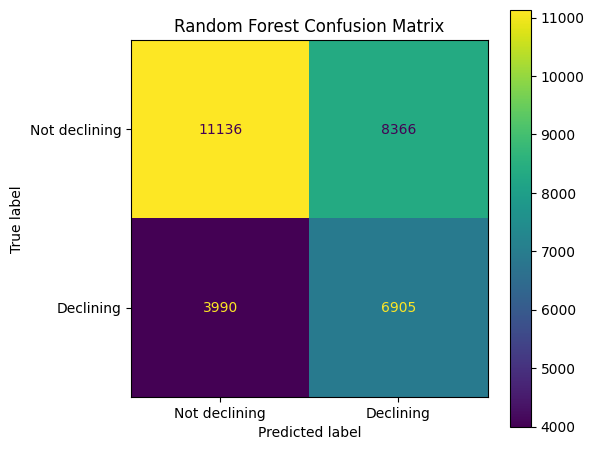

In [24]:
# Capstone — classification report and confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification report
print("Classification Report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Not declining", "Declining"],
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not declining", "Declining"]
).plot(ax=ax)

ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
# Capstone — generate ranked content recommendations

recommendations = df.loc[X_test.index].copy()

# Add the model's predicted probability of future decline
recommendations["decline_probability"] = y_test_proba

# Rank highest-risk content first
recommendations = recommendations.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

# Create action recommendations
recommendations["recommended_action"] = np.select(
    [
        recommendations["decline_probability"] >= 0.70,
        recommendations["decline_probability"] >= 0.50
    ],
    [
        "REFRESH_NOW",
        "REVIEW"
    ],
    default="MONITOR"
)

# Add a simple reason code
recommendations["reason_code"] = np.select(
    [
        recommendations["avg_position_first_period"] > 10,
        recommendations["ctr_first_pct"] < 1,
        recommendations["daily_impressions_first"] <=
            recommendations["daily_impressions_first"].quantile(0.25)
    ],
    [
        "WEAK_SEARCH_POSITION",
        "LOW_CTR",
        "LOW_SEARCH_VISIBILITY"
    ],
    default="GENERAL_DECLINE_RISK"
)

print("Ranked recommendations created.")
print("Total recommendations:", len(recommendations))

display(
    recommendations[
        [
            "client_hash_id",
            "content_hash_id",
            "decline_probability",
            "recommended_action",
            "reason_code",
            "daily_impressions_first",
            "ctr_first_pct",
            "avg_position_first_period"
        ]
    ].head(20)
)

Ranked recommendations created.
Total recommendations: 30397


,client_hash_id,content_hash_id,decline_probability,recommended_action,reason_code,daily_impressions_first,ctr_first_pct,avg_position_first_period
0,client_23a62021009f63c4,content_877c08cf2d1997a1,0.927897,REFRESH_NOW,WEAK_SEARCH_POSITION,1767.600000,0.049031,45.869447
1,client_23a62021009f63c4,content_39ad0976be228264,0.916978,REFRESH_NOW,WEAK_SEARCH_POSITION,744.800000,0.062657,43.328604
2,client_23a62021009f63c4,content_e70886c63f95aa1c,0.909394,REFRESH_NOW,WEAK_SEARCH_POSITION,1550.400000,0.030100,44.978593
3,client_23a62021009f63c4,content_605169c51403d450,0.909096,REFRESH_NOW,WEAK_SEARCH_POSITION,1256.333333,0.031839,47.716780
4,client_23a62021009f63c4,content_303393b256427d82,0.895720,REFRESH_NOW,WEAK_SEARCH_POSITION,707.466667,0.065963,43.125414
5,client_23a62021009f63c4,content_e7517465fc19e1cd,0.895609,REFRESH_NOW,WEAK_SEARCH_POSITION,2074.533333,0.057844,43.219573
6,client_23a62021009f63c4,content_28a2db61ca8bb267,0.892951,REFRESH_NOW,WEAK_SEARCH_POSITION,1370.600000,0.092417,30.487935
7,client_23a62021009f63c4,content_4ae1505344734f99,0.892088,REFRESH_NOW,WEAK_SEARCH_POSITION,730.333333,0.009128,50.500251
8,client_23a62021009f63c4,content_f87b08e3ac5a62b7,0.891963,REFRESH_NOW,WEAK_SEARCH_POSITION,1233.466667,0.097287,30.685654
9,client_23a62021009f63c4,content_7194f35ed434d1ec,0.886246,REFRESH_NOW,WEAK_SEARCH_POSITION,714.333333,0.139991,35.439202


In [26]:
# Capstone — public-safe recommendation summary

recommendation_summary = (
    recommendations
    .groupby(
        ["recommended_action", "reason_code"],
        observed=False
    )
    .agg(
        items=("decline_probability", "size"),
        average_decline_probability=("decline_probability", "mean")
    )
    .reset_index()
    .sort_values(
        "average_decline_probability",
        ascending=False
    )
)

recommendation_summary["average_decline_probability"] = (
    recommendation_summary["average_decline_probability"]
    .round(4)
)

print("Public-safe recommendation summary:")
display(recommendation_summary)

Public-safe recommendation summary:


,recommended_action,reason_code,items,average_decline_probability
7,REFRESH_NOW,WEAK_SEARCH_POSITION,324,0.7780
5,REFRESH_NOW,LOW_CTR,28,0.7267
6,REFRESH_NOW,LOW_SEARCH_VISIBILITY,31,0.7141
4,REFRESH_NOW,GENERAL_DECLINE_RISK,1,0.7029
10,REVIEW,LOW_SEARCH_VISIBILITY,124,0.6251
9,REVIEW,LOW_CTR,11345,0.5875
8,REVIEW,GENERAL_DECLINE_RISK,124,0.5603
11,REVIEW,WEAK_SEARCH_POSITION,3294,0.5542
2,MONITOR,LOW_SEARCH_VISIBILITY,2,0.4888
3,MONITOR,WEAK_SEARCH_POSITION,9409,0.4094


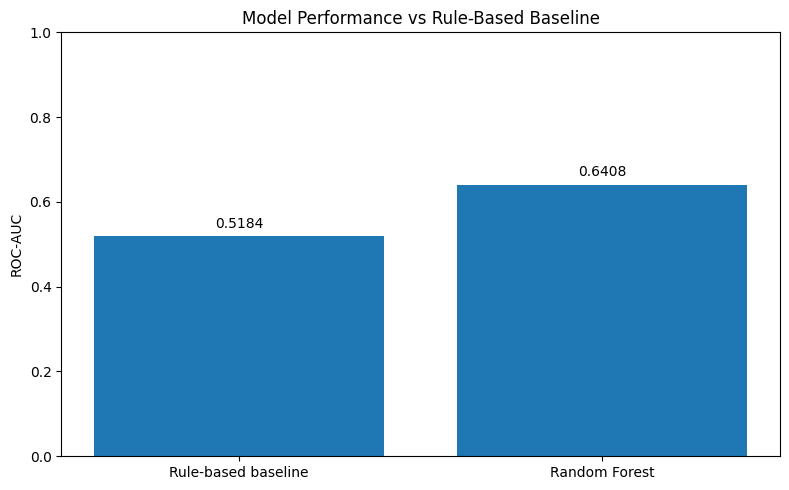

In [27]:
# Capstone — model vs baseline chart

import matplotlib.pyplot as plt

methods = ["Rule-based baseline", "Random Forest"]
auc_values = [baseline_auc, model_auc]

plt.figure(figsize=(8, 5))
plt.bar(methods, auc_values)

plt.ylabel("ROC-AUC")
plt.title("Model Performance vs Rule-Based Baseline")
plt.ylim(0, 1)

for i, value in enumerate(auc_values):
    plt.text(
        i,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

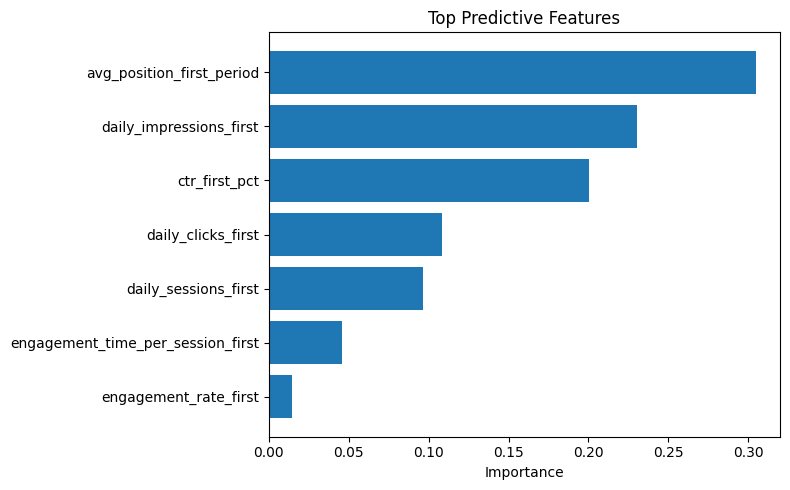

In [28]:
# Capstone — feature importance chart

top_features = feature_importance.head(7).sort_values(
    "importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.title("Top Predictive Features")

plt.tight_layout()
plt.show()

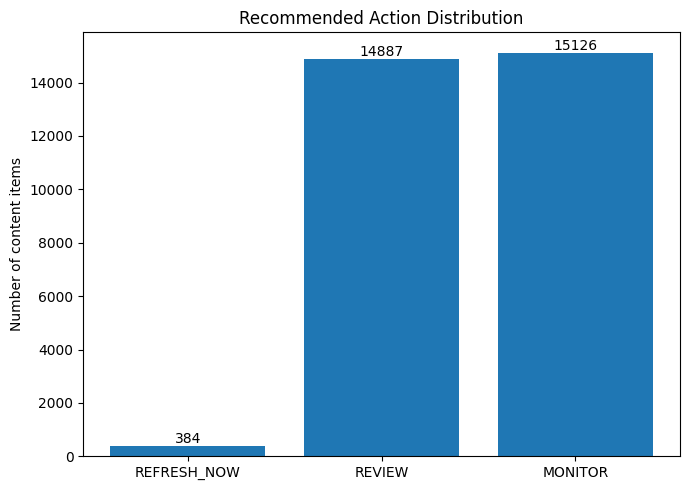

In [29]:
# Capstone — recommendation distribution chart

action_counts = (
    recommendations["recommended_action"]
    .value_counts()
    .reindex(
        ["REFRESH_NOW", "REVIEW", "MONITOR"],
        fill_value=0
    )
)

plt.figure(figsize=(7, 5))

plt.bar(
    action_counts.index,
    action_counts.values
)

plt.ylabel("Number of content items")
plt.title("Recommended Action Distribution")

for i, value in enumerate(action_counts.values):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [30]:
# Capstone — final results summary

auc_difference = model_auc - baseline_auc

print("CAPSTONE RESULTS SUMMARY")
print("=" * 40)

print(f"Dataset size: {len(df):,} client-content items")
print(f"Declining items: {df['is_declining_label'].sum():,}")
print(f"Declining rate: {df['is_declining_label'].mean() * 100:.2f}%")

print("\nPerformance:")
print(f"Rule-based baseline ROC-AUC: {baseline_auc:.4f}")
print(f"Random Forest ROC-AUC:       {model_auc:.4f}")
print(f"Difference:                  {auc_difference:+.4f}")

if auc_difference > 0:
    print("\nConclusion: The Random Forest outperformed the rule-based baseline.")
elif auc_difference < 0:
    print("\nConclusion: The Random Forest did not outperform the baseline.")
else:
    print("\nConclusion: The Random Forest matched the baseline.")

CAPSTONE RESULTS SUMMARY
Dataset size: 151,981 client-content items
Declining items: 54,472
Declining rate: 35.84%

Performance:
Rule-based baseline ROC-AUC: 0.5184
Random Forest ROC-AUC:       0.6408
Difference:                  +0.1224

Conclusion: The Random Forest outperformed the rule-based baseline.


## 5. Limitations

This analysis is designed as a decision-support system rather than a causal model of search ranking.

The results measure observed associations between historical search-performance signals and subsequent changes in impressions. They do not establish that any particular content change, refresh, or optimization would cause rankings or traffic to improve.

The outcome label is a constructed operational definition: a decline of at least 20% in average daily Google Search impressions between the feature period and the outcome period.

The analysis uses March 2026 data and therefore represents a limited observation window. Results may differ across other time periods, websites, content types, or search environments.

The dataset contains anonymized client and content identifiers. No client names, domains, URLs, private queries, or credentials are exposed in the public analysis.

The recommendations should therefore be interpreted as ranked review priorities, not guaranteed predictions of future search performance.

## 6. Ranked Recommendations

The model output is used as a prioritization system for content review.

Items with higher predicted probability of future impression decline receive higher priority. The recommended actions are:

1. **REFRESH_NOW** — highest predicted decline risk; prioritize for human review.
2. **REVIEW** — moderate predicted decline risk; investigate before deciding on an action.
3. **MONITOR** — lower predicted decline risk; continue observing performance.

The reason codes provide additional directional context, such as weak search position, low CTR, or low search visibility.

These recommendations are decision-support outputs. They do not imply that refreshing a page will cause Google rankings or impressions to increase.

## Reproducibility

The analysis was developed in Google Colab using Python, DuckDB, pandas, NumPy, and scikit-learn.

The notebook contains the complete workflow used to construct the dataset, engineer features, define the outcome, build the baseline, train the Random Forest model, evaluate the results, and generate ranked recommendations.

Repository:

https://github.com/Ikramkhan-gif1/FlyRank-ML-Internship

The capstone notebook is located under:

`work/notebooks/capstone.ipynb`

# ML-12 — Demo, Social Post & Employer Summary

## 5-Minute Demo Outline

### 0:00–0:45 — Problem
Explain the research question: can historical search-performance signals help prioritize content that may experience future search-impression decline?

### 0:45–1:30 — Data
Explain that the analysis uses anonymized FlyRank warehouse data from March 2026 and operates at the client-content level.

### 1:30–2:15 — Method
Explain the March 1–15 feature period, March 16–31 outcome period, the 20% impression-decline label, the rule-based baseline, and the Random Forest model.

### 2:15–3:15 — Results
Show the ROC-AUC comparison between the baseline and Random Forest, followed by the feature-importance chart.

### 3:15–4:15 — Recommendations
Show how model probabilities are converted into REFRESH_NOW, REVIEW, and MONITOR priorities.

### 4:15–5:00 — Limitations
Explain that the system is directional decision support and does not establish causal effects on Google rankings or traffic.

---

## Social-Post Cut

I built a machine-learning content opportunity scoring system using anonymized FlyRank search-performance data.

The project compares a simple rule-based baseline with a Random Forest model to prioritize content showing signs of future search-impression decline.

The result is an evidence-based ranking workflow with model evaluation, feature analysis, and actionable review priorities — while avoiding claims about Google's algorithm or causal SEO impact.

---

## Employer-Facing Summary

I developed an end-to-end machine-learning workflow using a large anonymized search-performance dataset, including data aggregation, feature engineering, leakage checks, baseline construction, model training, and evaluation.

I compared a Random Forest classifier against a rule-based baseline using ROC-AUC and converted model predictions into ranked content-review recommendations.

The project demonstrates practical experience in Python, DuckDB, pandas, scikit-learn, model validation, reproducible analysis, and communicating ML results as decision-support insights.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

#### Unit of Analysis

Each observation represents one unique combination of an anonymized client and content item.

#### Feature Construction

Predictive features are calculated exclusively from March 1–15, 2026. These include:

- average daily impressions
- daily clicks
- click-through rate
- average search position
- daily sessions
- engagement rate
- engagement time per session

#### Outcome Definition

The outcome is a binary operational label.

A content item is labeled `1` when its average daily Google Search impressions decrease by at least 20% between the feature period and the outcome period. Otherwise it is labeled `0`.

Because the two periods contain different numbers of days, impressions are normalized to average daily impressions before calculating the percentage change.

#### Baseline

A rule-based baseline combines two first-period signals:

- impression-level risk
- search-position risk

The resulting score assigns content to MONITOR, REVIEW, or REFRESH_NOW priority groups.

#### Machine-Learning Model

A Random Forest classifier is trained to predict the binary decline label using only first-period features.

#### Validation

The dataset is divided into an 80% training set and a 20% held-out test set using stratified sampling and a fixed random seed of 42.

ROC-AUC is the primary evaluation metric because the capstone is fundamentally a ranking/prioritization problem.

Accuracy, precision, recall, and F1-score are also reported as secondary metrics.

#### Leakage Checks

The future-period variables used to calculate the outcome are explicitly excluded from the predictive feature set.

The analysis also checks for missing predictive values and examines client overlap between the training and test sets.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The Random Forest model and rule-based baseline are evaluated on the same held-out test set.

The primary comparison is ROC-AUC. A higher ROC-AUC indicates better ability to rank content items according to their likelihood of experiencing the defined future impression decline.

The model-versus-baseline chart below provides the primary performance comparison.

Feature importance is used to describe which first-period signals contributed most to the Random Forest's predictions.

The results should be interpreted as observed predictive performance on this dataset and evaluation design, rather than evidence of causal effects on search rankings.

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts

The capstone produces the following research artifacts:

1. Model-versus-baseline ROC-AUC comparison.
2. Random Forest feature-importance chart.
3. Recommendation distribution chart.
4. Classification report and confusion matrix.
5. Public-safe recommendation summary.

These artifacts provide the evidence used in the deployed research paper.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
